In [1]:
# Setting up the notebook
import sys
sys.path.append("../scripts")

In [2]:
# Import statements
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown

from config import DATA_DIR, REQUESTS_DIR, RESPONSES_DIR, SCRIPTS_DIR

import functions as func

# 1. PRE-PROCESSING

## 1.1 Creation of Data Table

In [3]:
# Creation of dataframes for subsequent analysis
requests_df = func.create_df_of_requests(REQUESTS_DIR)
responses_df = func.create_df_of_responses(RESPONSES_DIR)
joined_df = func.join_requests_and_responses(requests_df, responses_df)

## 1.2 Solving Pre-Requisites

### 1.2.1 Defining unique location IDs by clustering

**PURPOSE**

The coordinates provided are floats (created by transformation of the original 'real' coordinates). Analyses requiring comparison of unique locations necessitate assignment of a unique location ID. We posited that small differences in floating point numbers might in reality refer to the same location. A clustering function was developed to assign locations that are tightly spread within a defined cut-off (e.g., 10 m) to the same location ID.

#### Attempt 1: Clustering by DBSCAN

In [4]:
# Calling DBSCAN clustering function and calculating the maximum distance between two points having the same loc_id.
df_dbscan = (func.add_max_distance_per_loc_id(
    func.group_locations_DBSCAN(joined_df)
    )
    .sort_values(by="max_group_distance_m", ascending=[False])
    .loc[:, ["route_id", "date", "time", "task_id", "lat", "lon", "loc_id", "max_group_distance_m"]]
    )

df_dbscan.head()

,route_id,date,time,task_id,lat,lon,loc_id,max_group_distance_m
2324803,O05,2022-06-14,08:51:32,3791,0.630755,0.197739,38731,90.495819
973313,627,2022-06-10,19:12:07,48,0.630912,0.197620,38731,90.495819
971839,627,2022-06-08,11:15:14,38927,0.630817,0.197705,38731,90.495819
972021,627,2022-06-08,19:12:16,132,0.631018,0.197524,38731,90.495819
972022,627,2022-06-08,19:12:16,133,0.630817,0.197705,38731,90.495819


_Conclusion_: The clustering function does not yield the expected result, with maximum distances up to 90 m vs. an intended clustering within 10 m. This can be explained by the way the DBSCAN algorithm works, as illustrated below.

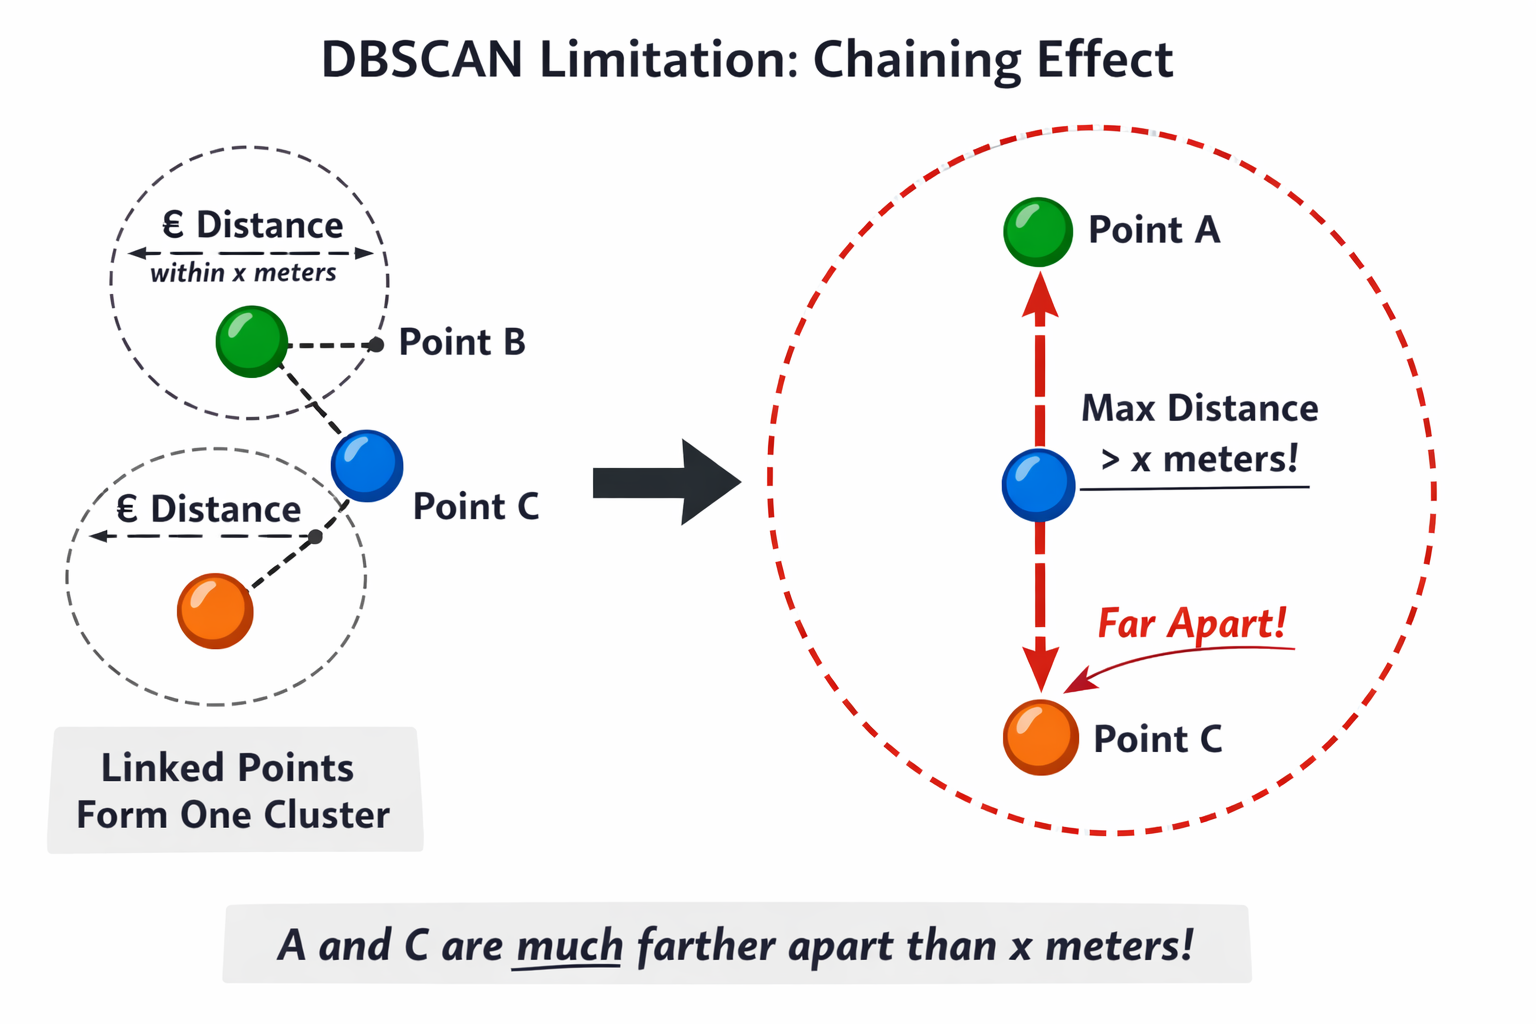

#### Attempt 2: Clustering by Grid / Cell Bucketing

In [5]:
df_cellbucket = (func.add_max_distance_per_loc_id(
    func.group_locations_cell_bucketing(joined_df)
    )
    .sort_values(by="max_group_distance_m", ascending=[False])
)

df_cellbucket.loc[
    :, ["route_id", "date", "time", "task_id", "lat", "lon", "loc_id", "max_group_distance_m"]
    ].head()

,route_id,date,time,task_id,lat,lon,loc_id,max_group_distance_m
595219,601,2022-06-15,06:35:24,58784,0.636125,0.146579,98275,12.778992
599147,601,2022-06-21,07:04:04,60542,0.636041,0.146657,98275,12.778992
595658,601,2022-06-15,19:11:37,5,0.636125,0.146579,98275,12.778992
598980,601,2022-06-21,06:47:06,60632,0.636041,0.146657,98275,12.778992
598981,601,2022-06-21,06:47:06,60542,0.636041,0.146657,98275,12.778992


_Conclusion_: The cell bucketing function works much better, with a maximum distance between location IDs of 12 m, which is relatively close to the intended 10 m. An explanation of how cell bucketing works is provided below.

![verschil dbscan en cell bucketing.png](<attachment:verschil dbscan en cell bucketing.png>)
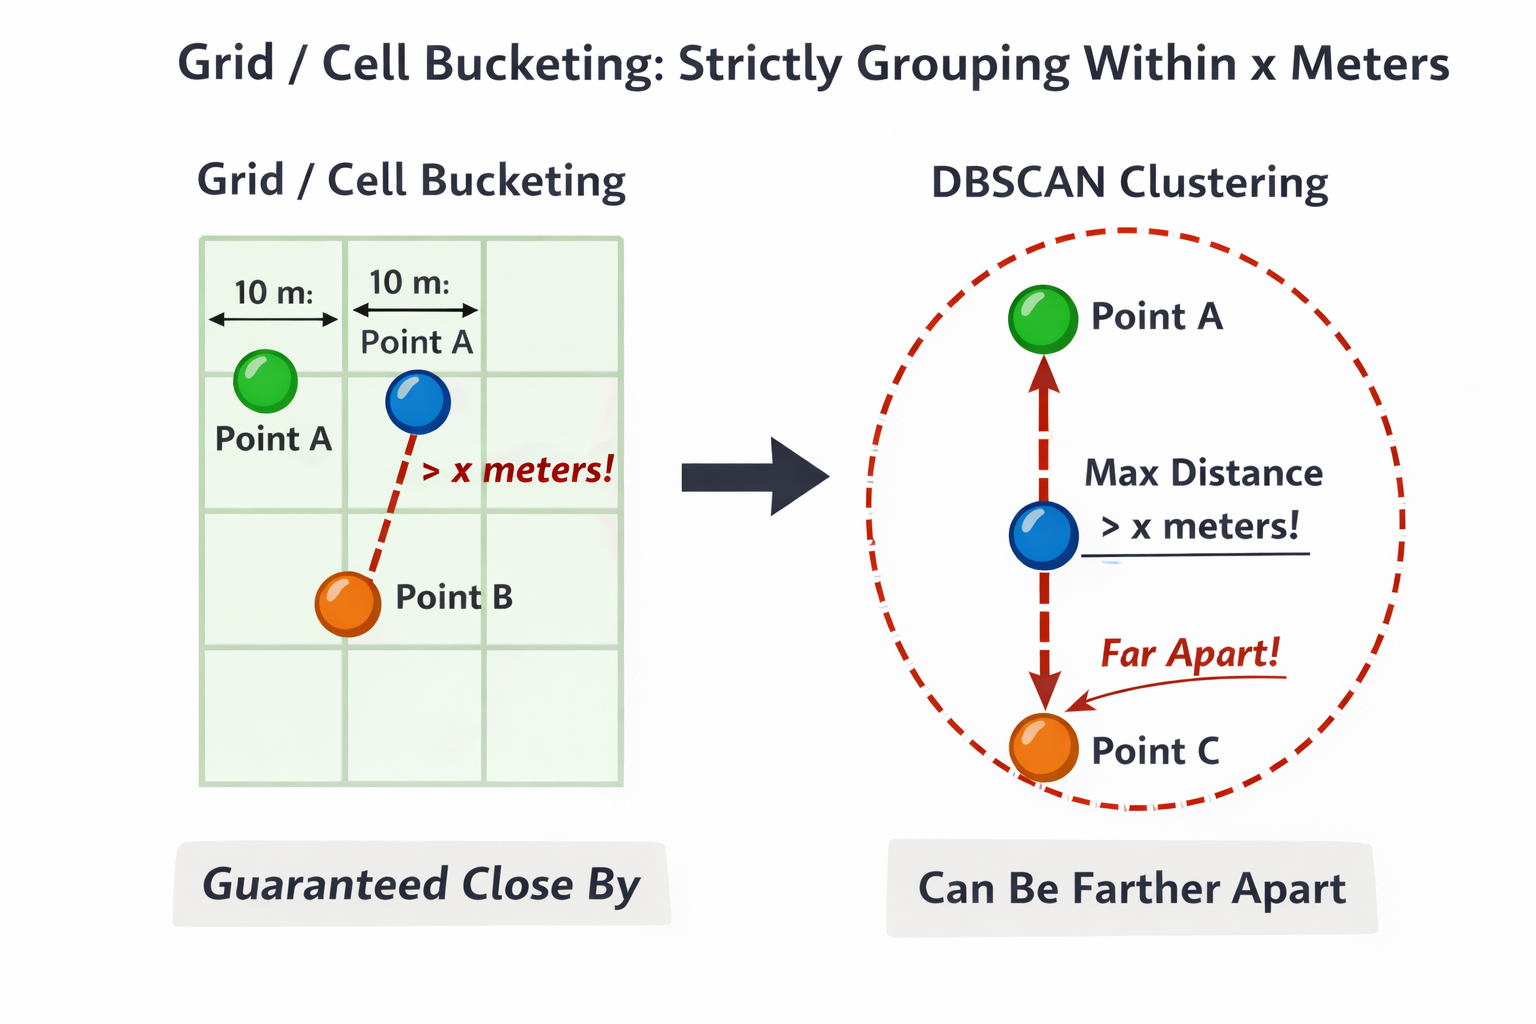

### 1.2.2 Finding time and task tresholds ("cut-off") for further analyses

**PURPOSE**

Time: requests follow a pulsed pattern, with a first wave of intense activity representing organization of the daily deliveries, which is our subject of interest. A second large activity peak is irrelevant for the analysis. We want to define where to set the "cursor". 

Tasks: similarly, we are only interested in those trips with a sufficient number of tasks, as these are most consequential for the analysis. 

#### Determining the Time Cut-Off

In [6]:
# Reading the Excel file
df, info= func.read_inputfile(DATA_DIR / "ModifiedQueryRows.xlsx")

file information: {'selected_depot': '0521', 'source': 'excel', 'filename': 'ModifiedQueryRows.xlsx'}


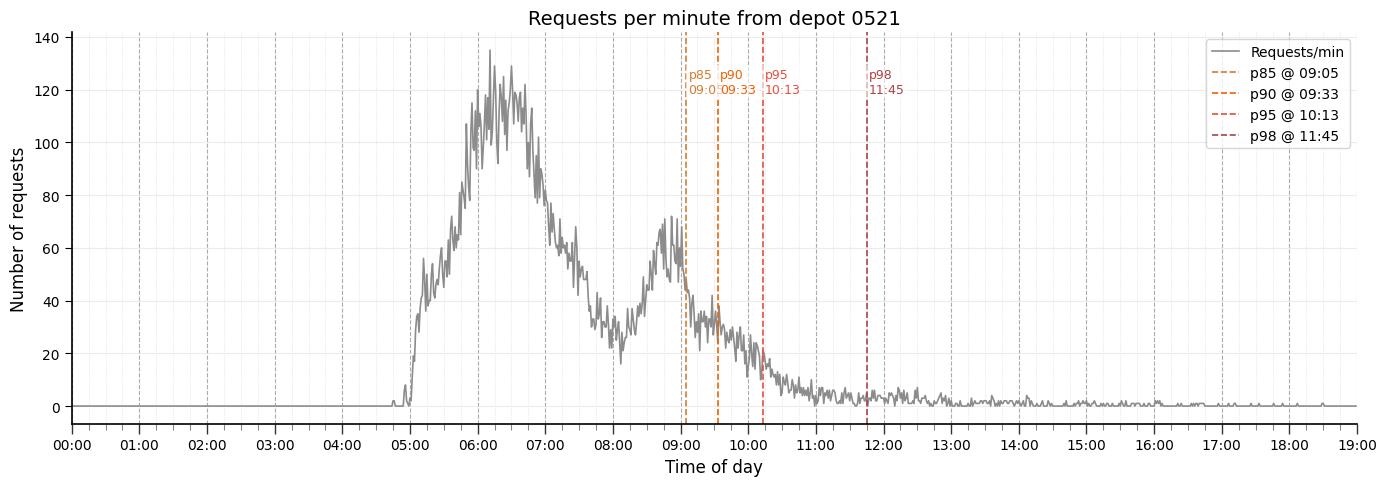

information: {'selected_depot': '0521', 'n_requests_kept': 18530}


(<Figure size 1400x500 with 1 Axes>,
 <Axes: title={'center': 'Requests per minute from depot 0521'}, xlabel='Time of day', ylabel='Number of requests'>,
 {'selected_depot': '0521', 'n_requests_kept': 18530})

In [7]:
func.define_cutoff_time(df, depot="0521")

#### Determing the Cut-Off for Number of Tasks

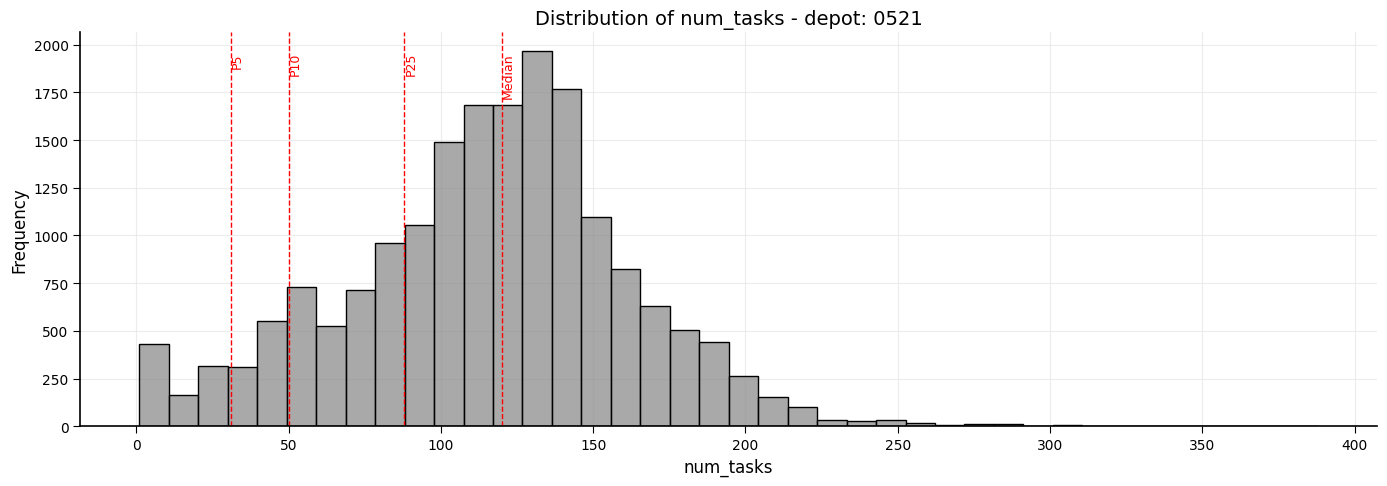

information: {'selected_depot': {'0521'}, 'n_rows': 18530}


In [8]:
summary, info = func.define_cutoff_stops(df, depot="0521")

In [9]:
# Choice of time threshold
thresh = pd.to_datetime("11:00:00").time()

# 2. DATA EXPLORATION

We take a closer look at the dataset to assess the situation in more details, before proceeding with the actual data analysis.

In [10]:
# Filter on time and tasks thresholds (11 AM and >= 30 tasks)
filtered_time_and_tasks_df= func.filter_on_cutoff_time_and_tasks(df)

# Annotate with request sequence numbers to compare first and consecutive requests within a trip
annotated_with_request_seq = func.annotate_requests_with_sequence_num(filtered_time_and_tasks_df)

# Create a table with 1 row per trip (route/day)
aggregated_trips_df = func.aggregate_trips(filtered_time_and_tasks_df)

**_Question 1: Analysis of Requests_**

In the project background, it is indicated that drivers are not always 100% satisfied with the route proposed by the optimization software. We are interested in knowing the distribution of requests per trip (= one routeID, one day); and the type of requests. The data tell us that there are indeed multiple requests per trip; and that the most common type of request is 'EstimateTime', whereby the driver fixes the tasks and simply asks for a calculation of the route (not an optimization). 

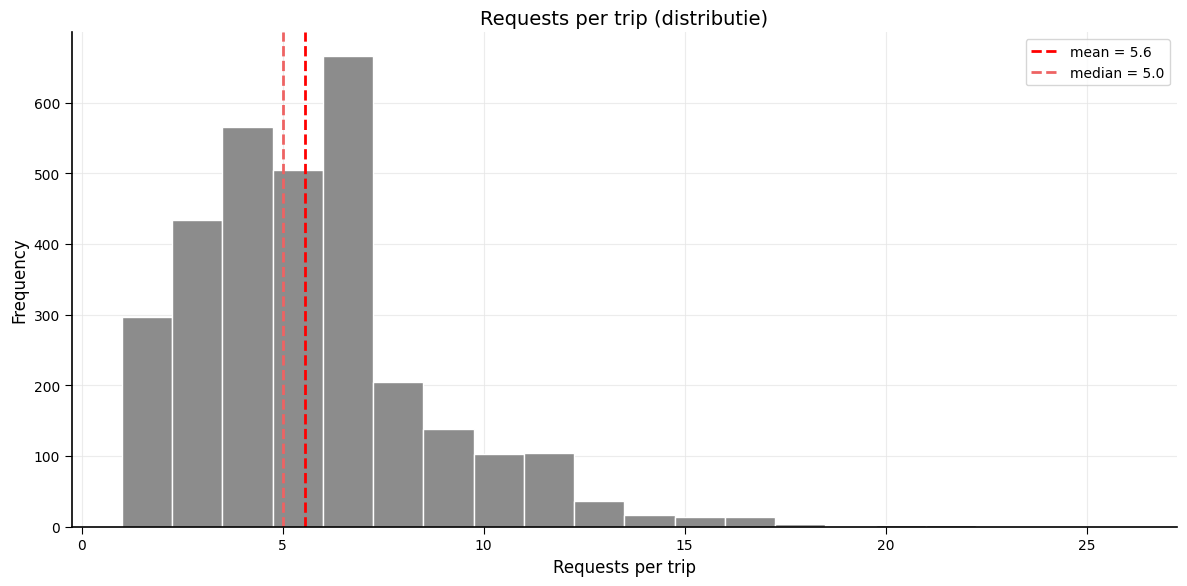

In [11]:
route_summary = func.summarize_requests(trip_df=aggregated_trips_df, show_plots=True)

interactive(children=(Dropdown(description='Route:', options=('0521_301', '0521_302', '0521_303', '0521_304', …

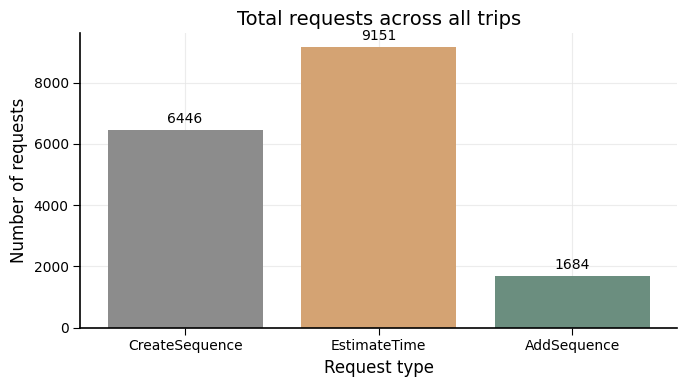

In [12]:
aggregate_route_df = func.summarize_type_of_requests(trip_df = aggregated_trips_df)

**_Question 2: Number of Tasks_**

We determined that drivers most frequently use 'EstimateTime' requests, fixing tasks. We are interested in knowing whether the number of tasks remains constant over requests, or not. In the latter case, does the number of tasks increase or decrease? We find that the number of tasks remains constant in only 17.3% of cases. For those cases where the number of tasks varies, the most frequent change is a decrease in the number of tasks (i.e., "first > last").

c:\Users\KristofVandekerckhov\OneDrive - Opero BV\2. DATA SCIENCE\git-repos\learning-driver-preferences\notebooks\../scripts\functions.py:1047: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


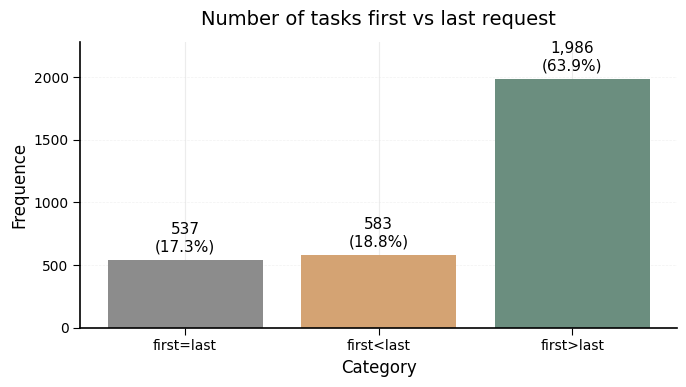

In [13]:
trip_task_var_df, summary_trip_var_df = func.task_variability_within_trips(filtered_time_and_tasks_df)

A more granular view...

In [14]:
func.plot_task_variability_in_trips(trip_task_var_df)

interactive(children=(Dropdown(description='Route:', options=('0521_301', '0521_302', '0521_303', '0521_304', …

# 3. DATA ANALYSIS

## 3.1 GRANULAR ANALYSIS

**RESEARCH QUESTION**

Two optimization models are used in combination: model 1 assigns tasks to routeIDs (regions), model 2 predicts the optimal sequence of locations (the optimal "trip"). Our objective is to evaluate the most common change made by the user: a change in the number of taskIDs (which would suggest non-optimality of model 1) or a change in the sequence of taskIDs (locations) (which would suggest non-optimality of model 2).

A change in the **_number of tasks_** was already concluded in the exploratory analysis. This section therefore focuses on some approaches to evaluating a change in the **_sequence of tasks_**.

### 3.1.1 Calculating Levenshtein Distance

Levenshtein distance is a string metric that measures the minimum number of single-character edits—insertions, deletions, or substitutions—required to transform one string into another. It therefore provides a combined measure of the change in the **number** of locations, and the change in the **order** of locations (the latter requiring both a deletion and an insertion).

We find that most trips involve a rather modest number of mutations (high frequency of small Levenshtein distance), although the distribution is long-tailed.

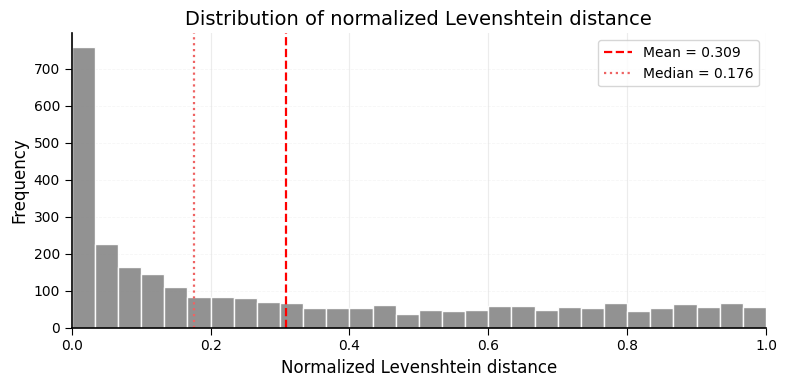

In [15]:
func.plot_distribution_levensthein(
        func.compute_levenshtein_from_df(annotated_with_request_seq, responses_dir=RESPONSES_DIR)
    )

### 3.1.2 Calculating Kendal-Tau Distance

Kendall Tau distance measures how dissimilar two rankings are by counting the number of discordant pairs — i.e., pairs of items whose relative order differs between the two rankings.

c:\Users\KristofVandekerckhov\OneDrive - Opero BV\2. DATA SCIENCE\git-repos\learning-driver-preferences\notebooks\../scripts\functions.py:2108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compare_order)
c:\Users\KristofVandekerckhov\OneDrive - Opero BV\2. DATA SCIENCE\git-repos\learning-driver-preferences\notebooks\../scripts\functions.py:2226: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_order

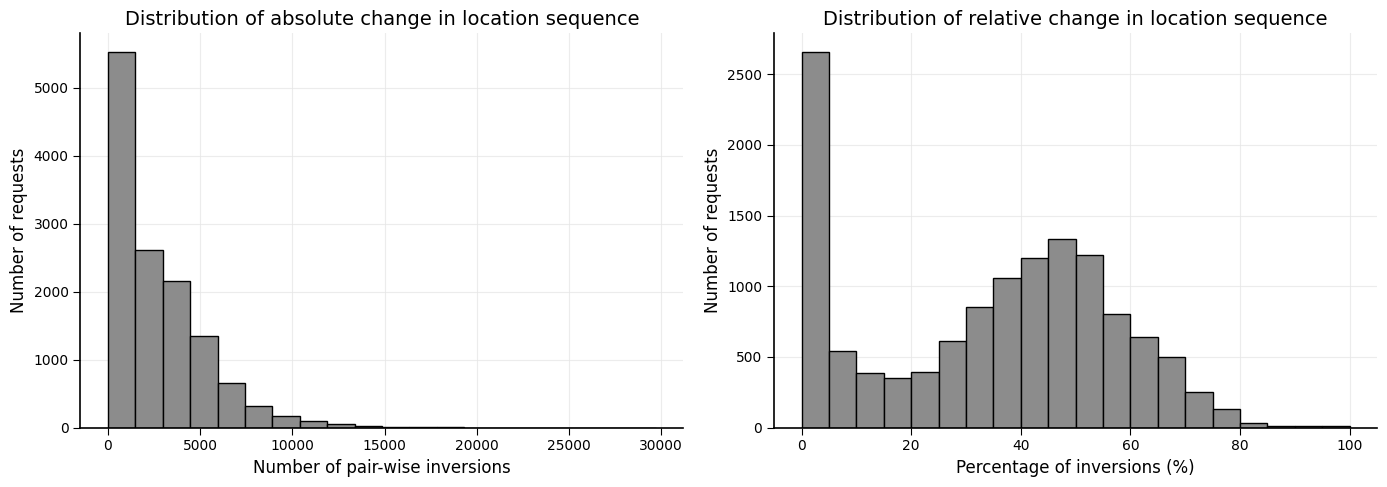

In [16]:
dfOrderChangedCount = func.add_order_change_count(
    func.add_order_changed(
        func.add_location_change_metrics(
        func.add_location_count_changed(df_cellbucket)
        )
    )
)

request_level = (
    dfOrderChangedCount[["route_id", "date", "request_id", "order_changed", 
            "order_changes_count", "order_changes_pct"]]
    .drop_duplicates()
)

changed_requests = request_level.query("order_changed == True")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of inversions
axes[0].hist(changed_requests["order_changes_count"], bins=20, edgecolor='black')
axes[0].set_xlabel("Number of pair-wise inversions")
axes[0].set_ylabel("Number of requests")
axes[0].set_title("Distribution of absolute change in location sequence")

# Percentage of inversions
axes[1].hist(changed_requests["order_changes_pct"], bins=20, edgecolor='black')
axes[1].set_xlabel("Percentage of inversions (%)")
axes[1].set_ylabel("Number of requests")
axes[1].set_title("Distribution of relative change in location sequence")

plt.tight_layout()

The distribution of relative changes in location sequence (i.e., the number of locations out of the total number of locations for which the order has changed) is bimodal. There is a pronounced spike near 0–5% (indicating many requests with minimal reordering), and a second, broader peak centered roughly around 40–50%, forming an approximately bell-shaped distribution for higher-change requests (≈15% and above).

## 3.2 CHANGE IMPACT ANALYSIS

**RESEARCH QUESTION**

The project's base hypothesis states that the model predictions are deemed non-optimal given the extent of human intervention observed to yield final routes. The trueness of this hypothesis deserves further assessment: does human intervention produce a more optimal result?

For this, the total distance to be driven following the model's recommendations can be compared to the distance to be driven after all human interventions. As taskIDs are not constant within regions and days (i.e., tasks are assumed to migrate between regions), an aggregated computation across all regions connected to warehouse 0521 will be performed. This is based on the assumption that taskIDs may change within routeIDs (per day) due to assignment to other routeIDs of the same warehouse. 

*STEP 1: Evaluation of Assumption*

In [17]:
filtered_requests_df = requests_df[
    requests_df["time"] < thresh
    ].loc[
        :, ["route_id", "date", "time", "request_type", "location_id"]
        ]

counted_tasks_df = func.count_tasks_per_sequence(filtered_requests_df)
select_compare_start_end_df = func.select_compare_start_and_end(counted_tasks_df)

Text(0.5, 1.0, 'Change in number of tasks over warehouse 0521 between start and end of shift')

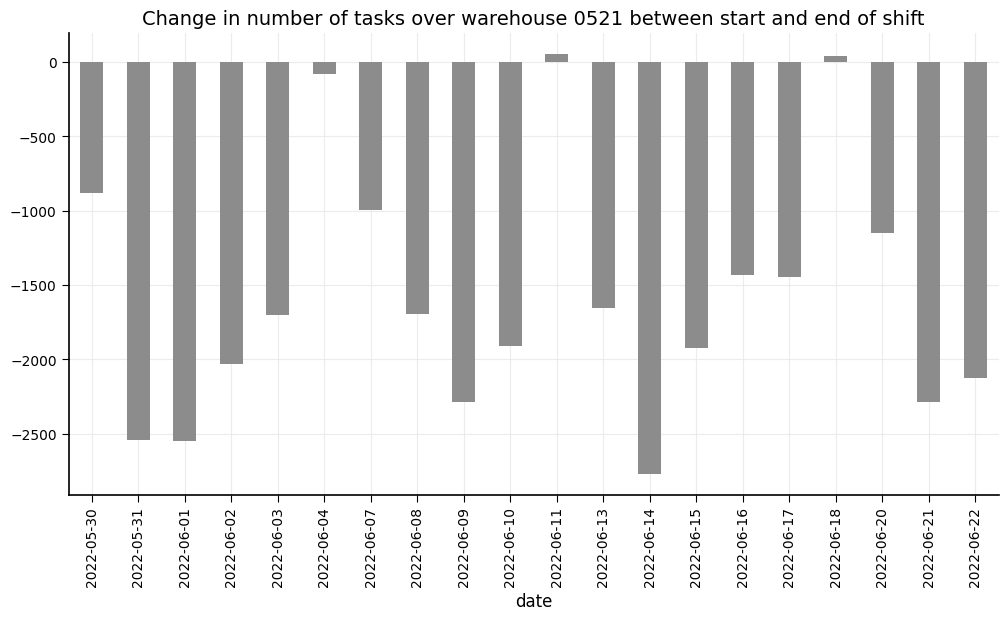

In [18]:
# Verifying the assumption
plt.style.use(SCRIPTS_DIR / "plot_style.mplstyle")

ax = (select_compare_start_end_df.groupby("date")["abs_diff_end_start"]
    .sum()
    .reset_index(name="diff_per_day")
    .plot(x="date", y="diff_per_day", kind="bar", legend=False))

ax.set_title("Change in number of tasks over warehouse 0521 between start and end of shift")

The assumption when evaluated at the level of warehouse 0521 appears to be false. This finding, although consistent with observations made during exploratory analysis, is surprising as it suggests the reason for the repeated requests (and non-compliance with the route proposed by the optimization software) is not motivated by disagreement with the route itself, but prompted by a change in the overall workload. 

The same analysis is performed at the level of all warehouses for robustness of the evaluation.

In [19]:
df_all_depots, info= func.read_inputfile(DATA_DIR / "ModifiedQueryRows.xlsx", depot = None)

# Needed dfs for analysis
filtered_time_and_tasks_df_all= func.filter_on_cutoff_time_and_tasks(df_all_depots)
trip_task_var_df_all, summary_trip_var_df_all = func.task_variability_within_trips(filtered_time_and_tasks_df_all, show_plots = False)

file information: {'selected_depot': 'ALL', 'source': 'excel', 'filename': 'ModifiedQueryRows.xlsx'}


c:\Users\KristofVandekerckhov\OneDrive - Opero BV\2. DATA SCIENCE\git-repos\learning-driver-preferences\notebooks\../scripts\functions.py:1047: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


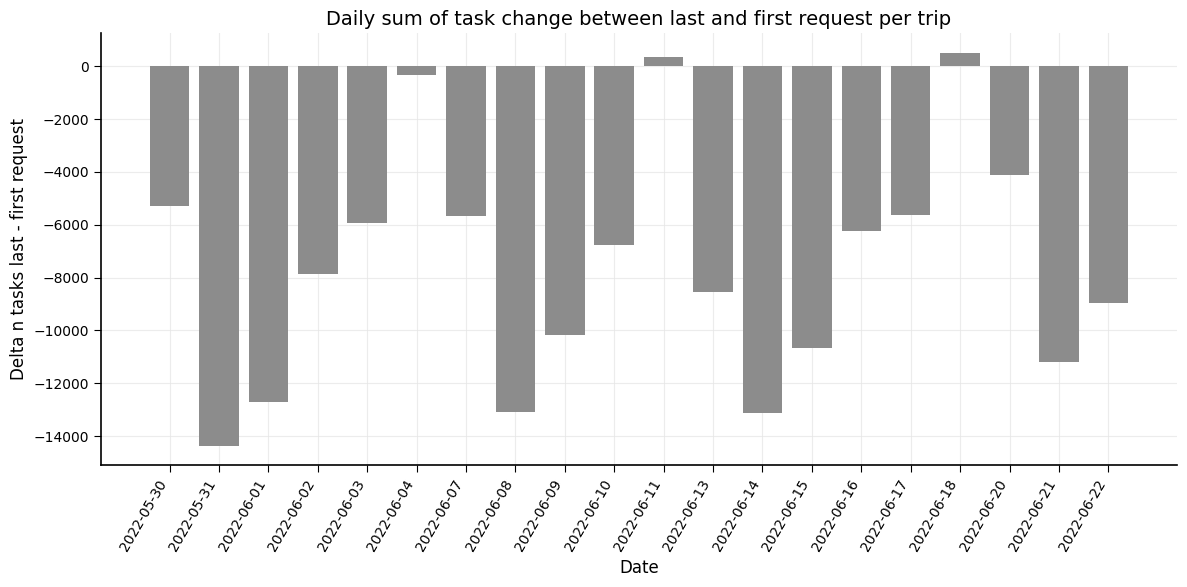

In [20]:
delta_df = func.delta_n_tasks_first_last_req_per_day(trip_task_var_df_all)

**_CONCLUSION_**

The assumption is clearly false. Further comparison of the total distance between model output and human output is not useful. The data suggest that the assigned workload is the primary cause of the frequent number of route calculation requests.